In [1]:
import httpimport

In [2]:
import sys
with httpimport.github_repo('MimaxSimm', 'trPL_Analysis', ref='master'):
    import trPL_importClass

<string>:497: SyntaxWarning: invalid escape sequence '\m'
<string>:502: SyntaxWarning: invalid escape sequence '\m'
<string>:555: SyntaxWarning: invalid escape sequence '\m'


In [3]:
import matplotlib.pyplot as plt
import numpy as np
from os.path import isfile, join
from importlib import reload

In [14]:
# Encapsulation seems to hold, if done PROPERLY

trPLs_Previous = trPL_importClass.trPL_measurement_series(r"D:\\Maxim\\20250128-LPtrPL-FAPI\\FAPI27-Spot1\\APD_Start", BG = 1.55, thickness = 450e-9, TRPL_denoise = 20, mode = "auto", retime = True, importPL=True)
trPLs_Previous.TRPLs_files

Lambda Laser set to: 7.050000e-07
Spot diameter set to: 2.720000e-04
Film thickness set to: 4.500000e-07
Beam dump ratio set to: 2.100000e-01
BG, Nc and Nv set to:1.55 2e+18 2e+18
['M0-FAPI27_3600s_10kHz_ND1_350cps_0.0200054uW.dat', 'M1-FAPI27_3600s_10kHz_ND2_1110cps_0.0757555uW.dat', 'M2-FAPI27_3600s_10kHz_ND4_480cps_0.26897699999999997uW.dat', 'M3-FAPI27_3600s_10kHz_ND5_1120cps_1.21695uW.dat']


['M0-FAPI27_3600s_10kHz_ND1_350cps_0.0200054uW.dat',
 'M1-FAPI27_3600s_10kHz_ND2_1110cps_0.0757555uW.dat',
 'M2-FAPI27_3600s_10kHz_ND4_480cps_0.26897699999999997uW.dat',
 'M3-FAPI27_3600s_10kHz_ND5_1120cps_1.21695uW.dat']

In [33]:
# Encapsulation seems to hold, if done PROPERLY

trPLs_Target = trPL_importClass.trPL_measurement_series(r".\\TwoStep", BG = 1.55, thickness = 800e-9, TRPL_denoise = None, mode = "auto", retime = True, importPL=True)
trPLs_Target.TRPLs_files

Lambda Laser set to: 7.050000e-07
Spot diameter set to: 2.720000e-04
Film thickness set to: 8.000000e-07
Beam dump ratio set to: 2.100000e-01
BG, Nc and Nv set to:1.55 2e+18 2e+18
['M0-FAPITarget1_3600s_5kHz_ND2_390cps_0.00925856uW.dat', 'M1-FAPITarget1_3600s_5kHz_ND3_460cps_0.0379171uW.dat', 'M2-FAPITarget1_2400s_5kHz_ND4_490cps_0.143372uW.dat', 'M3-FAPITarget1_2400s_5kHz_ND5_630cps_0.582206uW.dat']


['M0-FAPITarget1_3600s_5kHz_ND2_390cps_0.00925856uW.dat',
 'M1-FAPITarget1_3600s_5kHz_ND3_460cps_0.0379171uW.dat',
 'M2-FAPITarget1_2400s_5kHz_ND4_490cps_0.143372uW.dat',
 'M3-FAPITarget1_2400s_5kHz_ND5_630cps_0.582206uW.dat']

In [40]:
# Encapsulation seems to hold, if done PROPERLY

trPLs_Ref1 = trPL_importClass.trPL_measurement_series(r".\\TwoStep\\Ref1", BG = 1.55, thickness = 800e-9, TRPL_denoise = None, mode = "auto", retime = True, importPL=True)
trPLs_Ref1.TRPLs_files

Lambda Laser set to: 7.050000e-07
Spot diameter set to: 2.720000e-04
Film thickness set to: 8.000000e-07
Beam dump ratio set to: 2.100000e-01
BG, Nc and Nv set to:1.55 2e+18 2e+18
['M0-FAPIRef1_3600s_10kHz_ND1_80cps_0.017990500000000003uW.dat', 'M1-FAPIRef1_3600s_10kHz_ND1_130cps_0.0784422uW.dat', 'M2-FAPIRef1_2400s_10kHz_ND1_320cps_0.286889uW.dat', 'M3-FAPIRef1_2400s_10kHz_ND1_1470cps_1.1627699999999999uW.dat']


['M0-FAPIRef1_3600s_10kHz_ND1_80cps_0.017990500000000003uW.dat',
 'M1-FAPIRef1_3600s_10kHz_ND1_130cps_0.0784422uW.dat',
 'M2-FAPIRef1_2400s_10kHz_ND1_320cps_0.286889uW.dat',
 'M3-FAPIRef1_2400s_10kHz_ND1_1470cps_1.1627699999999999uW.dat']

In [34]:
trPLs_Target.TRPLs_noise

[0, 0, 0, 0]

<>:36: SyntaxWarning: invalid escape sequence '\m'
<>:36: SyntaxWarning: invalid escape sequence '\m'
C:\Users\PL Measurator\AppData\Local\Temp\ipykernel_20376\1722722221.py:36: SyntaxWarning: invalid escape sequence '\m'
  a.set_xlabel("Time [$\mu$s]", fontsize=axis_fontsize)


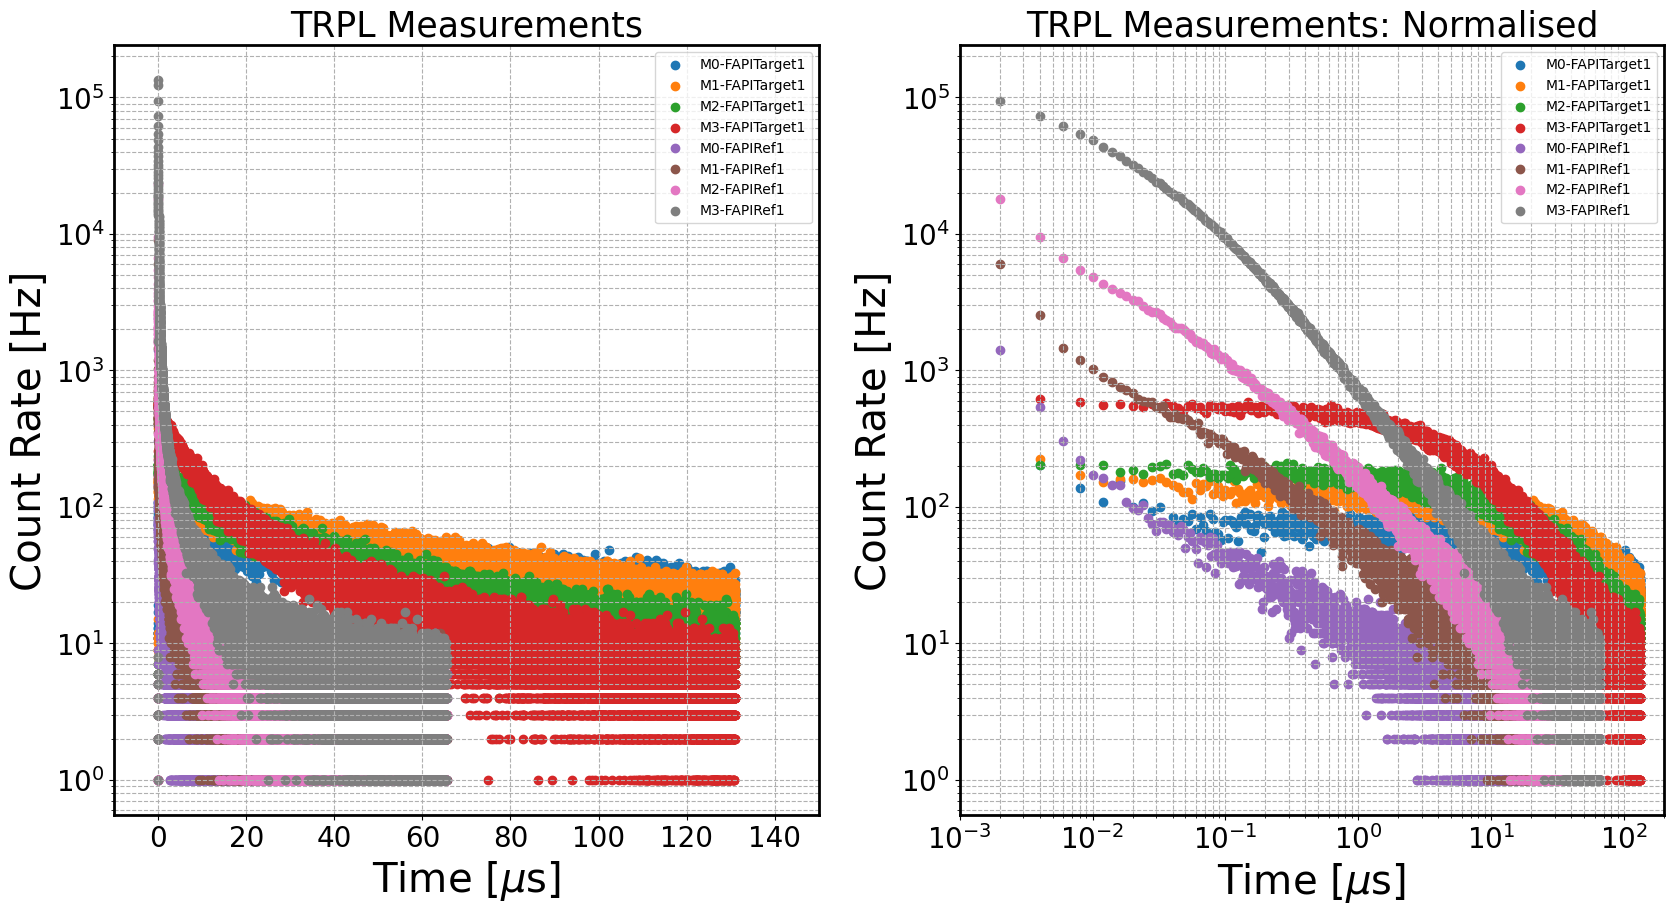

In [41]:
#Plot series
fig, ax = plt.subplots(1,2, figsize = (20,10))
idx_start = 3501
palette = ['#023047', '#126782', '#219EBC', '#8ECAE6', '#FFB703', '#FD9E02', '#FB8500', '#023047', '#126782', '#126782']

#legend = ["10us", "100us", "1ms", "3ms", "10us"]

selection = [0,1,2,3]
for i, (sPL) in enumerate(selection):
    ax[0].scatter(1e6*(trPLs_Target.TRPLs_ts[:,sPL]), trPLs_Target.TRPLs_raw[:,sPL], label = trPLs_Target.TRPL_sample[sPL], alpha = 1)
    ax[1].scatter(1e6*(trPLs_Target.TRPLs_ts[:,sPL]), trPLs_Target.TRPLs_raw[:,sPL], label = trPLs_Target.TRPL_sample[sPL], alpha = 1)

selection = [0,1,2,3]
for i, (sPL) in enumerate(selection):
    ax[0].scatter(1e6*(trPLs_Ref1.TRPLs_ts[:,sPL]), trPLs_Ref1.TRPLs_raw[:,sPL], label = trPLs_Ref1.TRPL_sample[sPL], alpha = 1)
    ax[1].scatter(1e6*(trPLs_Ref1.TRPLs_ts[:,sPL]), trPLs_Ref1.TRPLs_raw[:,sPL], label = trPLs_Ref1.TRPL_sample[sPL], alpha = 1)

    # ax[0].scatter(1e6*(trPLs_Previous.TRPLs_ts[:,sPL]), trPLs_Previous.TRPLs_raw[:,sPL], label = trPLs_Previous.TRPL_sample[sPL], alpha = 1)
    # ax[1].scatter(1e6*(trPLs_Previous.TRPLs_ts[:,sPL]), trPLs_Previous.TRPLs_raw[:,sPL], label = trPLs_Previous.TRPL_sample[sPL], alpha = 1)



ax[0].set_title('TRPL Measurements', fontsize=25)
ax[0].set_xlim([-10, 150])
ax[0].set_xscale("linear")
ax[1].set_title('TRPL Measurements: Normalised', fontsize=25)
ax[1].set_xlim([1e-3,200])
ax[1].set_xscale("log")
#ax[1].set_xlim([-1,20])

for a in ax:
    #a.set_ylim([1, 1e7])
    a.set_yscale("log")
    axis_fontsize = 29
    a.set_ylabel("Count Rate [Hz]", fontsize=axis_fontsize) 
    a.set_xlabel("Time [$\mu$s]", fontsize=axis_fontsize) 
    a.legend()
    axisTicks_fontsize = 20
    a.tick_params(axis='x', labelsize=axisTicks_fontsize)
    a.tick_params(axis='y', labelsize=axisTicks_fontsize)
    a.grid(visible = True, which = 'both', linestyle = '--')
    w_frame = 2
    a.spines["bottom"].set_linewidth(w_frame)
    a.spines["top"].set_linewidth(w_frame)
    a.spines["left"].set_linewidth(w_frame)
    a.spines["right"].set_linewidth(w_frame)

Number of exponentials for fit used is = [8, 8, 8, 8]

2.88e+13
1.26e+14
4.60e+14
1.86e+15


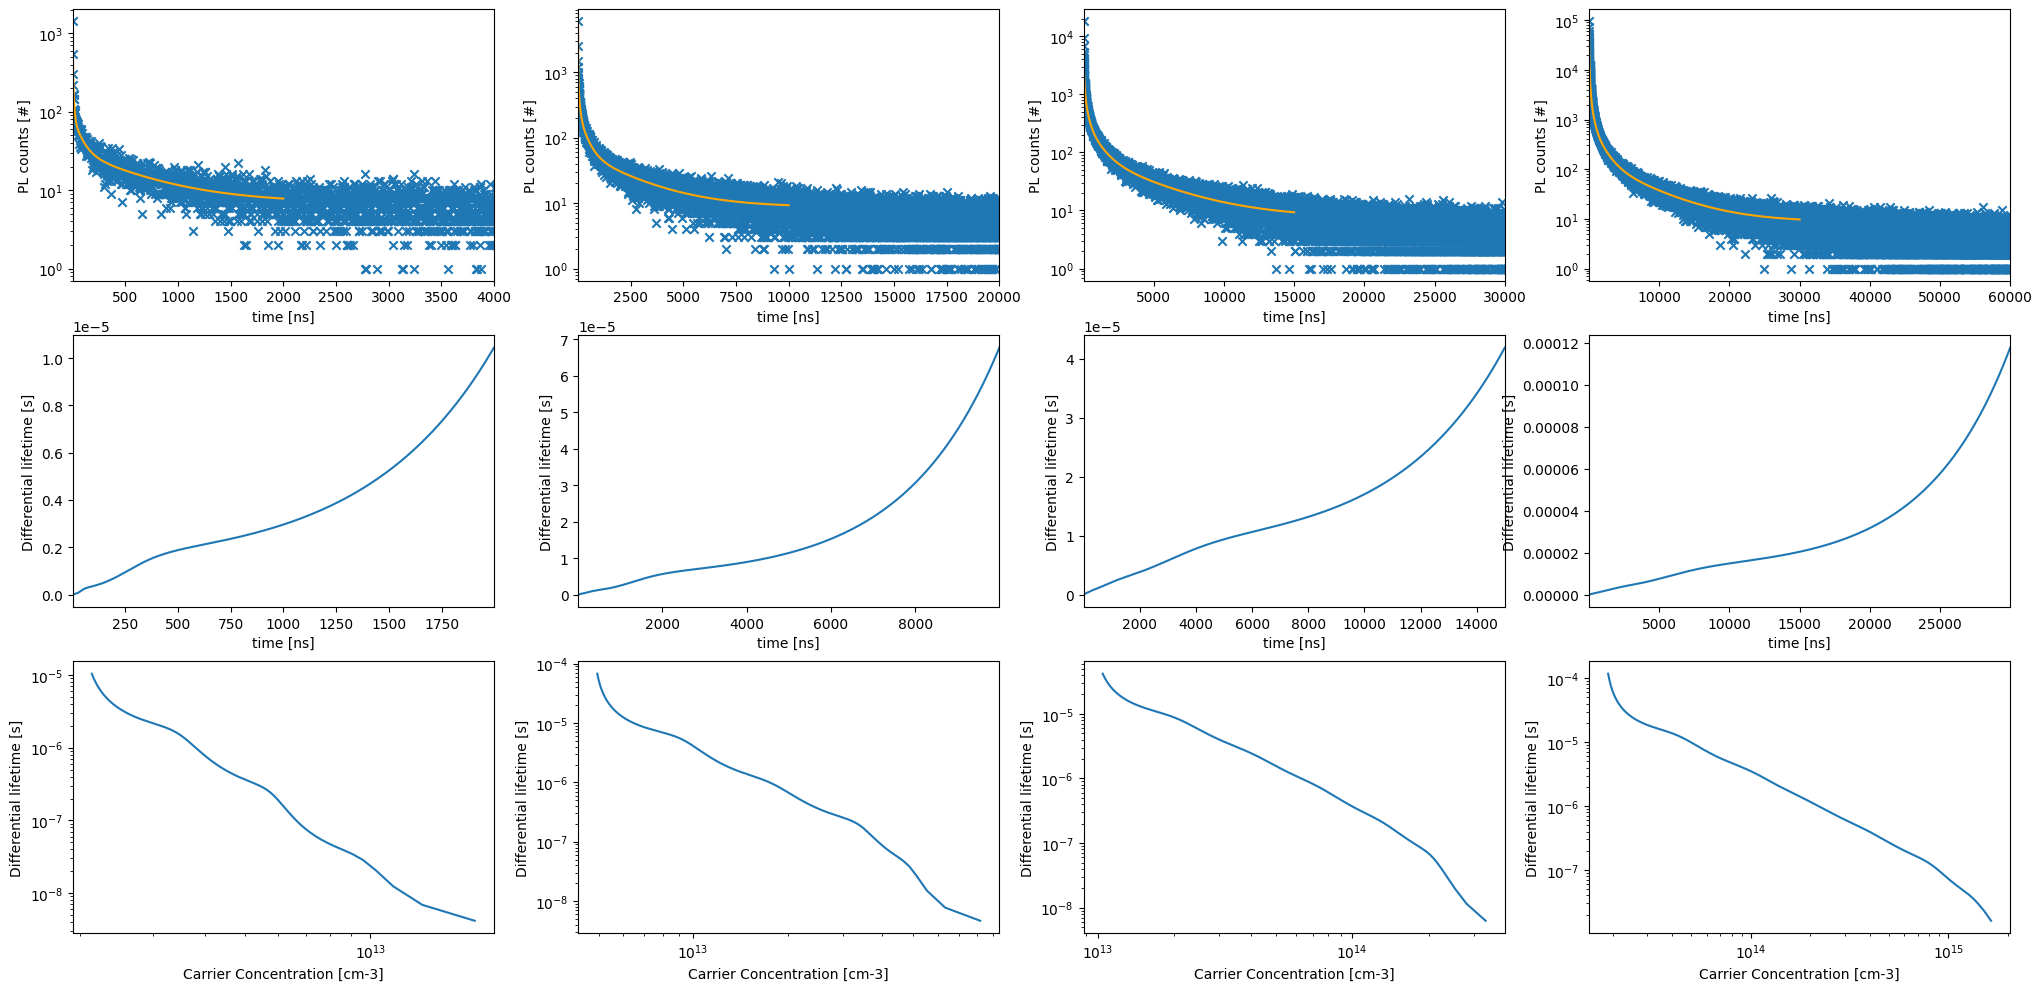

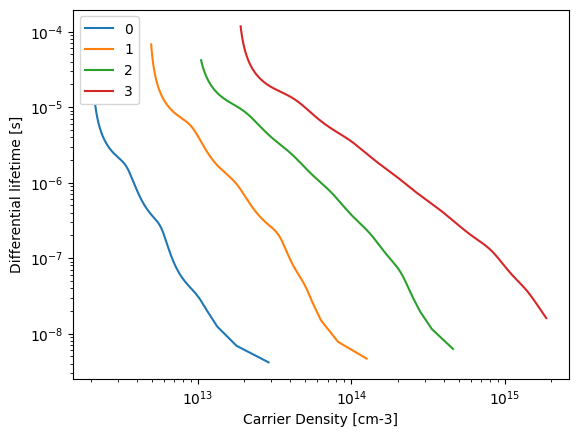

In [49]:
#Differential lifetimes
l = [2000, 10000, 15000, 30000]
n_exp = [8 for i in trPLs_Ref1.n0s]

times1, densities1, taudiffs1 = trPLs_Ref1.fit_difflifetimes(n_exp=n_exp, l2=l)

Number of exponentials for fit used is = [5, 5, 5, 5]

2.97e+13
1.22e+14
4.60e+14
1.87e+15


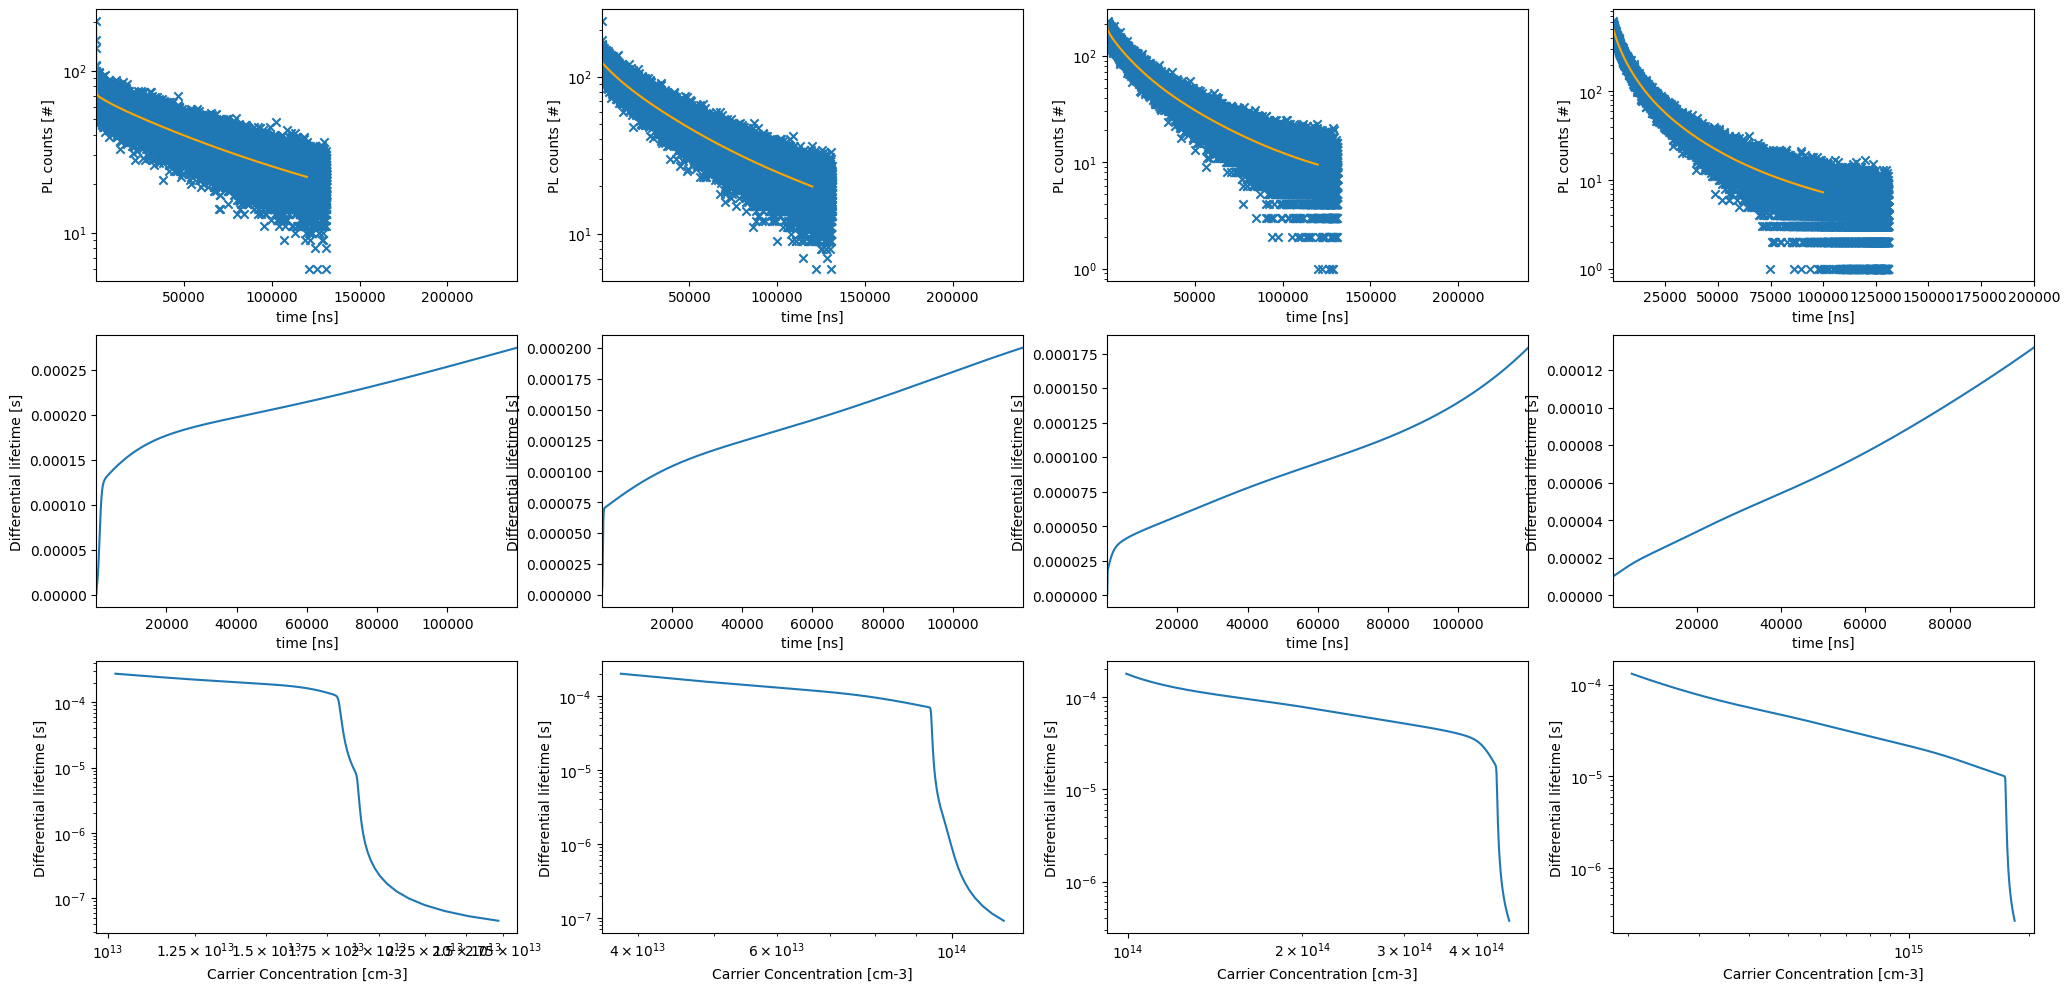

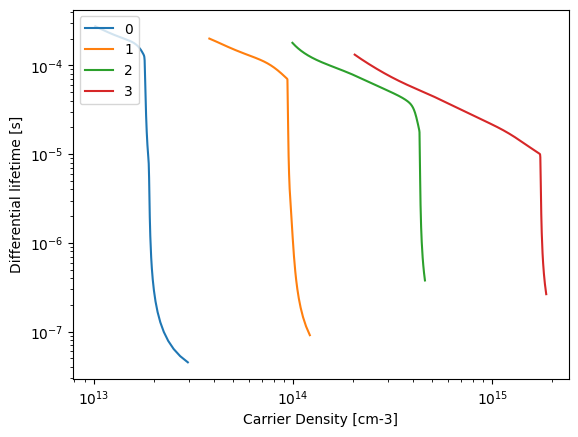

In [38]:
#Differential lifetimes
l = [120000, 120000, 120000, 100000, 60000]
n_exp = [5 for i in trPLs_Target.n0s]

times1, densities1, taudiffs1 = trPLs_Target.fit_difflifetimes(n_exp=n_exp, l2=l)

In [15]:
for i in range(5):
    print(i)

print(i)

0
1
2
3
4
4


<>:31: SyntaxWarning: invalid escape sequence '\m'
<>:31: SyntaxWarning: invalid escape sequence '\m'
C:\Users\PL Measurator\AppData\Local\Temp\ipykernel_20376\3809493341.py:31: SyntaxWarning: invalid escape sequence '\m'
  ax[0].set_xlabel("Time [$\mu$s]", fontsize=axis_fontsize)


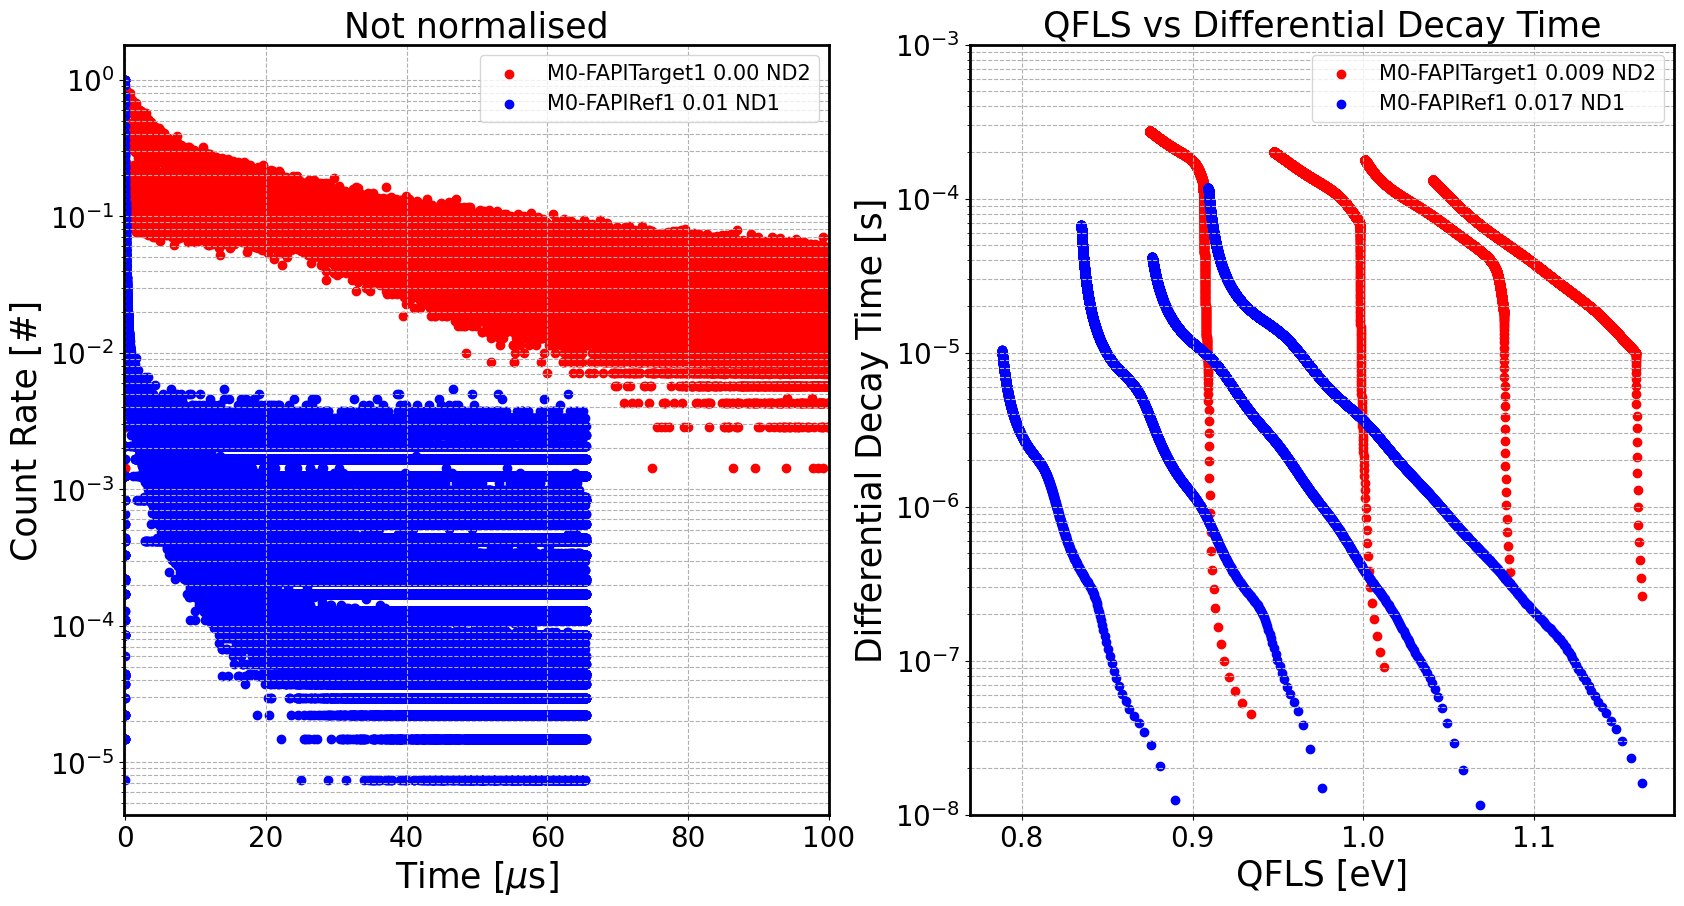

In [51]:
#Plot series
fig, ax = plt.subplots(1,2, figsize = (20,10))

#names = ["F", "wO", "CF3", "H", "MeO", "Pero-F", "Pero-wO", "Pero-CF3", "Pero-Yes", "Pero-No"]



for i, (sPLb) in enumerate(selection):
    if (i == 0):
        ax[0].scatter(1e6*(trPLs_Target.TRPLs_ts[:,sPLb]),trPLs_Target.TRPLs_n[:,sPLb], label = trPLs_Target.TRPL_sample[sPLb]+" "+str(1e6*trPLs_Target.TRPL_powers[sPLb])[:4]+" "+trPLs_Target.TRPL_NDs[sPLb], alpha = 1, color = "Red")
        ax[1].scatter((trPLs_Target.kT*np.log((trPLs_Target.densities[sPLb][:-1]*trPLs_Target.densities[sPLb][:-1])/(trPLs_Target.ni*trPLs_Target.ni))), trPLs_Target.diff_taus[sPLb], label = trPLs_Target.TRPL_sample[sPLb]+" "+str(1e6*trPLs_Target.TRPL_powers[sPLb])[:5]+" "+trPLs_Target.TRPL_NDs[sPLb], alpha = 1, color = "Red")
    else:
        ax[0].scatter(1e6*(trPLs_Target.TRPLs_ts[:,sPLb]),trPLs_Target.TRPLs_n[:,sPLb], alpha = 1, color = "Red")
        ax[1].scatter((trPLs_Target.kT*np.log((trPLs_Target.densities[sPLb][:-1]*trPLs_Target.densities[sPLb][:-1])/(trPLs_Target.ni*trPLs_Target.ni))), trPLs_Target.diff_taus[sPLb], alpha = 1, color = "Red")

for i, (sPLb) in enumerate(selection):
    if (i == 0):
        ax[0].scatter(1e6*(trPLs_Ref1.TRPLs_ts[:,sPLb]),trPLs_Ref1.TRPLs_n[:,sPLb], label = trPLs_Ref1.TRPL_sample[sPLb]+" "+str(1e6*trPLs_Ref1.TRPL_powers[sPLb])[:4]+" "+trPLs_Ref1.TRPL_NDs[sPLb], alpha = 1, color = "Blue")
        ax[1].scatter((trPLs_Ref1.kT*np.log((trPLs_Ref1.densities[sPLb][:-1]*trPLs_Ref1.densities[sPLb][:-1])/(trPLs_Ref1.ni*trPLs_Ref1.ni))), trPLs_Ref1.diff_taus[sPLb], label = trPLs_Ref1.TRPL_sample[sPLb]+" "+str(1e6*trPLs_Ref1.TRPL_powers[sPLb])[:5]+" "+trPLs_Ref1.TRPL_NDs[sPLb], alpha = 1, color = "Blue")
    else:
        ax[0].scatter(1e6*(trPLs_Ref1.TRPLs_ts[:,sPLb]),trPLs_Ref1.TRPLs_n[:,sPLb], alpha = 1, color = "Blue")
        ax[1].scatter((trPLs_Ref1.kT*np.log((trPLs_Ref1.densities[sPLb][:-1]*trPLs_Ref1.densities[sPLb][:-1])/(trPLs_Ref1.ni*trPLs_Ref1.ni))), trPLs_Ref1.diff_taus[sPLb], alpha = 1, color = "Blue")

axisTicks_fontsize = 20
axis_fontsize = 25
ax[0].set_title('Not normalised', fontsize=25)
ax[0].set_xlim([-0.1, 100])
#ax[0].set_ylim([1e-3,1.3])
ax[0].set_xscale("linear")
ax[0].set_ylabel("Count Rate [#]", fontsize=axis_fontsize) 
ax[0].set_xlabel("Time [$\mu$s]", fontsize=axis_fontsize) 

ax[1].set_title('QFLS vs Differential Decay Time', fontsize=25)
ax[1].set_xscale("linear")
ax[1].set_ylabel("Differential Decay Time [s]", fontsize=axis_fontsize) 
ax[1].set_xlabel("QFLS [eV]", fontsize=axis_fontsize)
#ax[1].set_xlim([1.51, 1.6])
ax[1].set_ylim([1e-8, 1e-3])


for i in range(2):
    
    #ax[i].set_ylim([100, 1e5])
    ax[i].set_yscale("log")#
    
    axis_fontsize = 29
    axisTicks_fontsize = 20
    ax[i].legend(fontsize = 15)
    ax[i].tick_params(axis='x', labelsize=axisTicks_fontsize)
    ax[i].tick_params(axis='y', labelsize=axisTicks_fontsize)
    ax[i].grid(visible = True, which = 'both', linestyle = '--')

    w_frame = 2
    ax[i].spines["bottom"].set_linewidth(w_frame)
    ax[i].spines["top"].set_linewidth(w_frame)
    ax[i].spines["left"].set_linewidth(w_frame)
    ax[i].spines["right"].set_linewidth(w_frame)
    
#plt.savefig('./DecayTimes.png', bbox_inches='tight')

In [10]:
trPLs.TRPL_savedata("./Data_trPLs_Wentao.csv")

,time: 00-22_2kHz-ND2-0.148uW-300s_4ns.dat,trPL denoised: 00-22_2kHz-ND2-0.148uW-300s_4ns.dat,trPL normalised: 00-22_2kHz-ND2-0.148uW-300s_4ns.dat,trPL raw: 00-22_2kHz-ND2-0.148uW-300s_4ns.dat,time: 01-37_2kHz-ND1-0.148uW-400s_4ns.dat,trPL denoised: 01-37_2kHz-ND1-0.148uW-400s_4ns.dat,trPL normalised: 01-37_2kHz-ND1-0.148uW-400s_4ns.dat,trPL raw: 01-37_2kHz-ND1-0.148uW-400s_4ns.dat,time: 02-18_2kHz-ND-0.148uW-400s_4ns.dat,trPL denoised: 02-18_2kHz-ND-0.148uW-400s_4ns.dat,...,trPL normalised: 07-21_2kHz-ND2-0.148uW-620s_4ns.dat,trPL raw: 07-21_2kHz-ND2-0.148uW-620s_4ns.dat,time: 08-21_2kHz-ND-0.148uW-650s_4ns.dat,trPL denoised: 08-21_2kHz-ND-0.148uW-650s_4ns.dat,trPL normalised: 08-21_2kHz-ND-0.148uW-650s_4ns.dat,trPL raw: 08-21_2kHz-ND-0.148uW-650s_4ns.dat,time: 09-33_2kHz-ND1-0.148uW-650s_4ns.dat,trPL denoised: 09-33_2kHz-ND1-0.148uW-650s_4ns.dat,trPL normalised: 09-33_2kHz-ND1-0.148uW-650s_4ns.dat,trPL raw: 09-33_2kHz-ND1-0.148uW-650s_4ns.dat
0,-2.680000e-07,-604.166667,-0.001072,4,-2.640000e-07,-78.125,-0.000068,0,-2.680000e-07,46.875,...,-0.001100,5,-2.640000e-07,298.076923,0.000133,6,-2.680000e-07,-153.846154,-0.000145,1
1,-2.640000e-07,-604.166667,-0.001072,4,-2.600000e-07,-78.125,-0.000068,0,-2.640000e-07,-265.625,...,-0.001809,3,-2.600000e-07,-86.538462,-0.000039,4,-2.640000e-07,-153.846154,-0.000145,1
2,-2.600000e-07,-604.166667,-0.001072,4,-2.560000e-07,-78.125,-0.000068,0,-2.600000e-07,984.375,...,0.000674,10,-2.560000e-07,490.384615,0.000219,7,-2.600000e-07,38.461538,0.000036,2
3,-2.560000e-07,-1437.500000,-0.002551,2,-2.520000e-07,-78.125,-0.000068,0,-2.560000e-07,-265.625,...,0.000674,10,-2.520000e-07,105.769231,0.000047,5,-2.560000e-07,-153.846154,-0.000145,1
4,-2.520000e-07,-187.500000,-0.000333,5,-2.480000e-07,-78.125,-0.000068,0,-2.520000e-07,46.875,...,-0.000035,8,-2.480000e-07,-86.538462,-0.000039,4,-2.520000e-07,-153.846154,-0.000145,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32763,1.307840e-04,1062.500000,0.001885,8,1.307880e-04,234.375,0.000203,1,1.307840e-04,46.875,...,0.004931,22,1.307880e-04,875.000000,0.000390,9,1.307840e-04,230.769231,0.000217,3
32764,1.307880e-04,2312.500000,0.004103,11,1.307920e-04,234.375,0.000203,1,1.307880e-04,1296.875,...,0.002093,14,1.307920e-04,875.000000,0.000390,9,1.307880e-04,230.769231,0.000217,3
32765,1.307920e-04,3979.166667,0.007061,15,1.307960e-04,-78.125,-0.000068,0,1.307920e-04,46.875,...,0.001384,12,1.307960e-04,1836.538462,0.000819,14,1.307920e-04,38.461538,0.000036,2
32766,1.307960e-04,1895.833333,0.003364,10,1.308000e-04,546.875,0.000474,2,1.307960e-04,984.375,...,0.002093,14,1.308000e-04,1644.230769,0.000733,13,1.307960e-04,615.384615,0.000579,5


In [11]:
trPLs.diff_savedata("./DecayTimes_5exponents.csv")

,time: 00-22_2kHz-ND2-0.148uW-300s_4ns.dat,density: 00-22_2kHz-ND2-0.148uW-300s_4ns.dat,qfls: 00-22_2kHz-ND2-0.148uW-300s_4ns.dat,tau_diff: 00-22_2kHz-ND2-0.148uW-300s_4ns.dat,time: 01-37_2kHz-ND1-0.148uW-400s_4ns.dat,density: 01-37_2kHz-ND1-0.148uW-400s_4ns.dat,qfls: 01-37_2kHz-ND1-0.148uW-400s_4ns.dat,tau_diff: 01-37_2kHz-ND1-0.148uW-400s_4ns.dat,time: 02-18_2kHz-ND-0.148uW-400s_4ns.dat,density: 02-18_2kHz-ND-0.148uW-400s_4ns.dat,...,qfls: 07-21_2kHz-ND2-0.148uW-620s_4ns.dat,tau_diff: 07-21_2kHz-ND2-0.148uW-620s_4ns.dat,time: 08-21_2kHz-ND-0.148uW-650s_4ns.dat,density: 08-21_2kHz-ND-0.148uW-650s_4ns.dat,qfls: 08-21_2kHz-ND-0.148uW-650s_4ns.dat,tau_diff: 08-21_2kHz-ND-0.148uW-650s_4ns.dat,time: 09-33_2kHz-ND1-0.148uW-650s_4ns.dat,density: 09-33_2kHz-ND1-0.148uW-650s_4ns.dat,qfls: 09-33_2kHz-ND1-0.148uW-650s_4ns.dat,tau_diff: 09-33_2kHz-ND1-0.148uW-650s_4ns.dat
0,4.000000e-09,1.186437e+15,1.138381,7.859313e-08,4.000000e-09,1.186437e+15,1.138381,2.263752e-08,4.000000e-09,1.186437e+15,...,1.138381,6.737243e-08,4.000000e-09,1.186437e+15,1.138381,5.233981e-08,4.000000e-09,1.186437e+15,1.138381,7.010466e-08
1,8.000000e-09,1.127564e+15,1.135561,8.099117e-08,8.000000e-09,9.942737e+14,1.128592,3.311392e-08,8.000000e-09,1.129843e+15,...,1.135092,7.270037e-08,8.000000e-09,1.099144e+15,1.134147,5.821727e-08,8.000000e-09,1.120637e+15,1.135220,7.722747e-08
2,1.200000e-08,1.073229e+15,1.132825,8.349457e-08,1.200000e-08,8.811408e+14,1.121900,3.581264e-08,1.200000e-08,1.079399e+15,...,1.132044,7.825583e-08,1.200000e-08,1.026160e+15,1.130341,6.452644e-08,1.200000e-08,1.064071e+15,1.132350,8.457676e-08
3,1.600000e-08,1.023026e+15,1.130171,8.609739e-08,1.600000e-08,7.880212e+14,1.115712,3.914331e-08,1.600000e-08,1.034174e+15,...,1.129212,8.393589e-08,1.600000e-08,9.644793e+14,1.126906,7.107135e-08,1.600000e-08,1.014918e+15,1.129730,9.194076e-08
4,2.000000e-08,9.765841e+14,1.127597,8.879260e-08,2.000000e-08,7.114722e+14,1.110051,4.318704e-08,2.000000e-08,9.933788e+14,...,1.126572,8.963181e-08,2.000000e-08,9.116963e+14,1.123788,7.763127e-08,2.000000e-08,9.717097e+14,1.127320,9.911228e-08
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24993,9.997600e-05,1.074416e+14,1.005323,2.369164e-04,NaN,NaN,NaN,NaN,9.997600e-05,4.341143e+13,...,0.993774,2.177958e-04,9.997600e-05,2.861233e+13,0.932023,3.489864e-04,9.997600e-05,3.235518e+13,0.938834,3.902643e-04
24994,9.998000e-05,1.074398e+14,1.005322,2.369187e-04,NaN,NaN,NaN,NaN,9.998000e-05,4.341091e+13,...,0.993773,2.177956e-04,9.998000e-05,2.861200e+13,0.932022,3.490043e-04,9.998000e-05,3.235484e+13,0.938833,3.902885e-04
24995,9.998400e-05,1.074380e+14,1.005321,2.369209e-04,NaN,NaN,NaN,NaN,9.998400e-05,4.341038e+13,...,0.993772,2.177953e-04,9.998400e-05,2.861167e+13,0.932022,3.490222e-04,9.998400e-05,3.235451e+13,0.938833,3.903126e-04
24996,9.998800e-05,1.074361e+14,1.005320,2.369232e-04,NaN,NaN,NaN,NaN,9.998800e-05,4.340986e+13,...,0.993771,2.177950e-04,9.998800e-05,2.861135e+13,0.932021,3.490401e-04,9.998800e-05,3.235418e+13,0.938832,3.903368e-04
